# InflationScope Brasil

### Análise da inflação brasileira entre 2015 e 2025

O projeto analisa o comportamento mensal do IPCA brasileiro e investiga se indicadores econômicos nacionais e internacionais estão associados às suas variações.

### Relevância do problema

A inflação afeta diretamente o poder de compra, o planejamento das famílias, das empresas e as decisões econômicas. Por isso, compreender seu comportamento e identificar indicadores associados às suas variações é relevante para analisar a economia brasileira.

### Pergunta de pesquisa

**Em que medida a inflação passada, a inflação dos Estados Unidos, a variação do dólar, a Selic e a atividade econômica estão associadas ao IPCA mensal brasileiro?**

### Variável resposta (y)

- **IPCA mensal do Brasil (%)**

### Variáveis explicativas (X)

- IPCA do mês anterior (%)
- Inflação mensal dos Estados Unidos (%)
- Variação mensal do dólar (%)
- Selic do mês anterior (%)
- Variação mensal do IBC-Br (%)

### Hipóteses iniciais

- Esperamos uma associação positiva entre o **IPCA do mês anterior** e o IPCA atual, indicando persistência da inflação.
- Esperamos encontrar alguma associação entre o IPCA brasileiro e a **inflação dos Estados Unidos**.
- Também esperamos alguma relação com a **variação do dólar**, a **Selic** e a **atividade econômica**, embora esses efeitos possam ocorrer com diferentes defasagens.

### Período e unidade de observação

- **Período principal:** 2015 a 2025
- **Unidade de observação:** cada linha da base final representa um mês.
- **Dimensão antes do tratamento:** 132 observações mensais e 7 colunas.
- **Dimensão após o tratamento:** 129 observações mensais e 7 colunas.

### Fontes e acesso

- **Banco Central do Brasil (SGS):** IPCA, dólar, Selic e IBC-Br  
  https://api.bcb.gov.br/dados/serie/
- **Bureau of Labor Statistics (BLS):** CPI dos Estados Unidos  
  https://api.bls.gov/publicAPI/v1/timeseries/data/

**Data de acesso:** 27/08/2026

Os dados foram obtidos por APIs públicas oficiais. Condições específicas de uso ou licenciamento devem ser consultadas nos respectivos portais oficiais.

### Dicionário das principais variáveis

| Variável | Tipo | Unidade | Descrição |
|---|---|---|---|
| mes | Data | mês | Mês de referência da observação |
| ipca | Numérica contínua | % ao mês | Inflação mensal brasileira |
| ipca_anterior | Numérica contínua | % ao mês | IPCA registrado no mês anterior |
| inflacao_eua | Numérica contínua | % ao mês | Inflação mensal dos Estados Unidos |
| var_dolar | Numérica contínua | % | Variação da cotação média mensal do dólar |
| selic_anterior | Numérica contínua | % ao mês | Selic acumulada no mês anterior |
| var_ibc_br | Numérica contínua | % | Variação mensal da atividade econômica brasileira |


In [1]:
%pip install -q tenacity

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from tenacity import (
    retry,
    stop_after_attempt,
    wait_exponential,
    retry_if_exception_type
)

DATA_INICIAL = "2015-01-01"
DATA_FINAL = "2025-12-31"

print("InflationScope Brasil")
print("Período:", DATA_INICIAL, "até", DATA_FINAL)

InflationScope Brasil
Período: 2015-01-01 até 2025-12-31


In [2]:
# ==========================================
# Funções para coleta no Banco Central
# ==========================================

@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(
        multiplier=1,
        min=4,
        max=10
    ),
    retry=retry_if_exception_type(
        requests.exceptions.RequestException
    ),
    reraise=True
)
def buscar_bcb(codigo, data_inicial, data_final):

    url = (
        f"https://api.bcb.gov.br/dados/serie/"
        f"bcdata.sgs.{codigo}/dados"
    )

    parametros = {
        "formato": "json",
        "dataInicial": data_inicial,
        "dataFinal": data_final
    }

    resposta = requests.get(
        url,
        params=parametros,
        timeout=60
    )

    resposta.raise_for_status()

    df = pd.DataFrame(resposta.json())

    df["data"] = pd.to_datetime(
        df["data"],
        format="%d/%m/%Y"
    )

    df["valor"] = pd.to_numeric(
        df["valor"],
        errors="coerce"
    )

    return df


def buscar_bcb_completo(codigo, inicio="01/01/2014"):

    parte1 = buscar_bcb(
        codigo,
        inicio,
        "31/12/2020"
    )

    parte2 = buscar_bcb(
        codigo,
        "01/01/2021",
        "31/12/2025"
    )

    df = pd.concat(
        [parte1, parte2],
        ignore_index=True
    )

    return (
        df
        .drop_duplicates(subset="data")
        .sort_values("data")
        .reset_index(drop=True)
    )

In [3]:
# ==========================================
# IPCA mensal - Brasil
# Série SGS 433
# ==========================================

ipca = buscar_bcb_completo(
    codigo="433",
    inicio="01/01/2015"
)

ipca = ipca.rename(columns={
    "data": "mes",
    "valor": "ipca"
})

print("Quantidade de meses:", len(ipca))

display(
    ipca.head().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "ipca": lambda x: f"{x:.3f}%".replace(".", ",")
    })
)

Quantidade de meses: 132


,mes,ipca
0,01/01/2015,"1,240%"
1,01/02/2015,"1,220%"
2,01/03/2015,"1,320%"
3,01/04/2015,"0,710%"
4,01/05/2015,"0,740%"


In [4]:
# ==========================================
# Dólar americano
# Série SGS 1 - Cotação de venda
# ==========================================

dolar_diario = buscar_bcb_completo(
    codigo="1",
    inicio="01/01/2014"
)

# Transformando os dados diários em meses
dolar_diario["mes"] = (
    dolar_diario["data"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Cotação média mensal
dolar = (
    dolar_diario
    .groupby("mes", as_index=False)["valor"]
    .mean()
    .rename(columns={
        "valor": "dolar"
    })
)

# Variação percentual em relação ao mês anterior
dolar["var_dolar"] = (
    dolar["dolar"]
    .pct_change(fill_method=None) * 100
)

print("Quantidade de meses:", len(dolar))

display(
    dolar.head().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "dolar": "{:.3f}",
        "var_dolar": lambda x: f"{x:.3f}%".replace(".", ",")
        if pd.notna(x) else "NaN"
    })
)

Quantidade de meses: 144


,mes,dolar,var_dolar
0,01/01/2014,2.382,NaN
1,01/02/2014,2.384,"0,062%"
2,01/03/2014,2.326,"-2,416%"
3,01/04/2014,2.233,"-4,012%"
4,01/05/2014,2.221,"-0,532%"


In [5]:
# ==========================================
# Taxa Selic mensal
# Série SGS 4390
# ==========================================

selic = buscar_bcb_completo(
    codigo="4390",
    inicio="01/01/2015"
)

selic = selic.rename(columns={
    "data": "mes",
    "valor": "selic"
})

print("Quantidade de meses:", len(selic))

display(
    selic.head().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "selic": lambda x: f"{x:.3f}%".replace(".", ",")
    })
)

Quantidade de meses: 132


,mes,selic
0,01/01/2015,"0,940%"
1,01/02/2015,"0,820%"
2,01/03/2015,"1,040%"
3,01/04/2015,"0,950%"
4,01/05/2015,"0,990%"


In [ ]:
# ==========================================
# IBC-Br - Índice de Atividade Econômica
# Série SGS 24364 - Com ajuste sazonal
# ==========================================

ibc = buscar_bcb_completo(
    codigo="24364",
    inicio="01/01/2014"
)

ibc = ibc.rename(columns={
    "data": "mes",
    "valor": "ibc_br"
})

# Variação percentual em relação ao mês anterior
ibc["var_ibc_br"] = (
    ibc["ibc_br"]
    .pct_change(fill_method=None) * 100
)

print("Quantidade de meses:", len(ibc))

display(
    ibc.head().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "ibc_br": "{:.3f}",
        "var_ibc_br": lambda x: f"{x:.3f}%".replace(".", ",")
        if pd.notna(x) else "NaN"
    })
)


In [7]:
# ==========================================
# CPI dos Estados Unidos
# Série CUSR0000SA0
# ==========================================

@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(
        multiplier=1,
        min=4,
        max=10
    ),
    retry=retry_if_exception_type(
        requests.exceptions.RequestException
    ),
    reraise=True
)
def buscar_cpi_eua(ano_inicial, ano_final):

    url = "https://api.bls.gov/publicAPI/v1/timeseries/data/"

    dados = {
        "seriesid": ["CUSR0000SA0"],
        "startyear": str(ano_inicial),
        "endyear": str(ano_final)
    }

    resposta = requests.post(
        url,
        json=dados,
        timeout=60
    )

    resposta.raise_for_status()

    serie = resposta.json()["Results"]["series"][0]["data"]

    df_cpi = pd.DataFrame(serie)

    # Mantendo apenas os meses M01 a M12
    df_cpi = df_cpi[
        df_cpi["period"].str.match(r"M(0[1-9]|1[0-2])")
    ].copy()

    # Criando a data
    df_cpi["mes"] = pd.to_datetime(
        df_cpi["year"]
        + "-"
        + df_cpi["period"].str.replace("M", "")
        + "-01"
    )

    # Valores inválidos, como "-", viram NaN
    df_cpi["cpi_eua"] = pd.to_numeric(
        df_cpi["value"],
        errors="coerce"
    )

    return df_cpi[["mes", "cpi_eua"]]


# A API é consultada em duas partes
cpi_eua = pd.concat([
    buscar_cpi_eua(2014, 2020),
    buscar_cpi_eua(2021, 2025)
])

cpi_eua = (
    cpi_eua
    .drop_duplicates(subset="mes")
    .sort_values("mes")
    .reset_index(drop=True)
)

# Inflação mensal americana
cpi_eua["inflacao_eua"] = (
    cpi_eua["cpi_eua"]
    .pct_change(fill_method=None) * 100
)

print("Quantidade de meses:", len(cpi_eua))

display(
    cpi_eua.tail().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "cpi_eua": "{:.3f}",
        "inflacao_eua": lambda x: f"{x:.3f}%".replace(".", ",")
        if pd.notna(x) else "NaN"
    })
)

Quantidade de meses: 144


,mes,cpi_eua,inflacao_eua
139,01/08/2025,323.291,"0,348%"
140,01/09/2025,324.245,"0,295%"
141,01/10/2025,nan,NaN
142,01/11/2025,325.063,NaN
143,01/12/2025,326.031,"0,298%"


In [ ]:
# ==========================================
# Junção e tratamento da base
# ==========================================

df = ipca.merge(
    dolar[["mes", "var_dolar"]],
    on="mes"
)

df = df.merge(
    selic[["mes", "selic"]],
    on="mes"
)

df = df.merge(
    ibc[["mes", "var_ibc_br"]],
    on="mes"
)

df = df.merge(
    cpi_eua[["mes", "inflacao_eua"]],
    on="mes"
)

# Período principal
df = df[
    (df["mes"] >= "2015-01-01") &
    (df["mes"] <= "2025-12-01")
].copy()

# Variáveis defasadas
df["ipca_anterior"] = df["ipca"].shift(1)
df["selic_anterior"] = df["selic"].shift(1)

# Mantendo somente as variáveis utilizadas
df = df[
    [
        "mes",
        "ipca",
        "ipca_anterior",
        "inflacao_eua",
        "var_dolar",
        "selic_anterior",
        "var_ibc_br"
    ]
]

print("Dimensão inicial:", df.shape)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

linhas_antes = len(df)

df = (
    df
    .dropna()
    .reset_index(drop=True)
)

print("\nLinhas removidas:", linhas_antes - len(df))
print("Dimensão final:", df.shape)

display(
    df.head().style.format({
        "mes": lambda x: x.strftime("%d/%m/%Y"),
        "ipca": "{:.3f}",
        "ipca_anterior": "{:.3f}",
        "inflacao_eua": "{:.3f}",
        "var_dolar": "{:.3f}",
        "selic_anterior": "{:.3f}",
        "var_ibc_br": "{:.3f}"
    })
)

print("\nTipos das variáveis na base final:")
print(df.dtypes)

valores_infinitos = np.isinf(
    df.select_dtypes(include="number")
).sum()

print("\nValores infinitos:")
print(valores_infinitos)


### Tratamento dos dados

A base consolidada inicialmente possuía **132 observações mensais e 7 colunas**.

Não foram encontrados registros duplicados. Os valores ausentes ocorreram principalmente pela criação das variáveis defasadas e pela ausência de informação necessária para calcular a inflação dos Estados Unidos em parte de 2025.

Como foram afetadas apenas **3 observações**, elas foram removidas. A base final utilizada na análise possui **129 meses completos e 7 colunas**.

A primeira observação não possui IPCA e Selic anteriores porque não existe um mês anterior dentro do período analisado.

O CPI dos Estados Unidos apresentou ausência em outubro de 2025. Por isso, a inflação de outubro e novembro de 2025 não foi preenchida artificialmente.

Os tipos das variáveis foram conferidos durante a preparação da base. As variáveis utilizadas na modelagem foram mantidas como numéricas e a coluna `mes` foi mantida como data. Também foi feita uma verificação de valores infinitos.

Não existem variáveis categóricas na base final, portanto não foi necessário aplicar codificação de categorias.

Valores extremos não foram removidos automaticamente, pois podem representar movimentos econômicos reais. Eles são analisados posteriormente por meio dos gráficos, dos maiores erros de previsão e das medidas de influência.


,quantidade,media,desvio_padrao,minimo,quartil_1,mediana,quartil_3,maximo
ipca,129.0,0.456,0.399,-0.680,0.230,0.410,0.710,1.620
ipca_anterior,129.0,0.461,0.406,-0.680,0.220,0.410,0.710,1.620
inflacao_eua,129.0,0.253,0.268,-0.792,0.104,0.236,0.373,1.256
var_dolar,129.0,0.637,3.713,-8.700,-1.940,0.608,2.598,12.505
selic_anterior,129.0,0.764,0.322,0.130,0.490,0.830,1.050,1.280
var_ibc_br,129.0,0.067,1.431,-9.107,-0.328,0.053,0.541,4.552


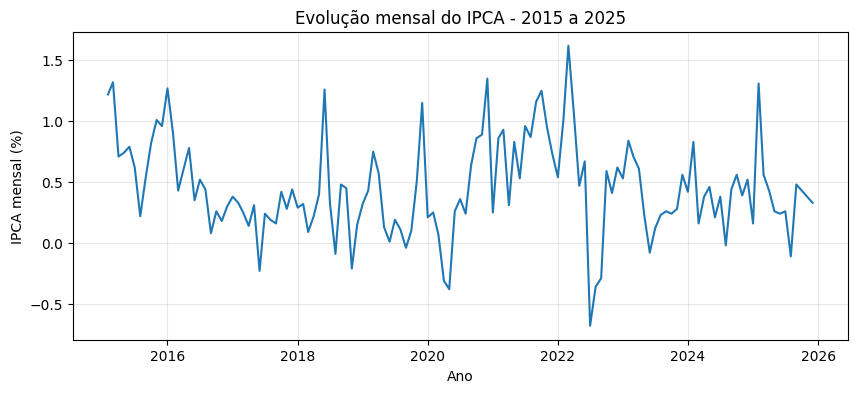

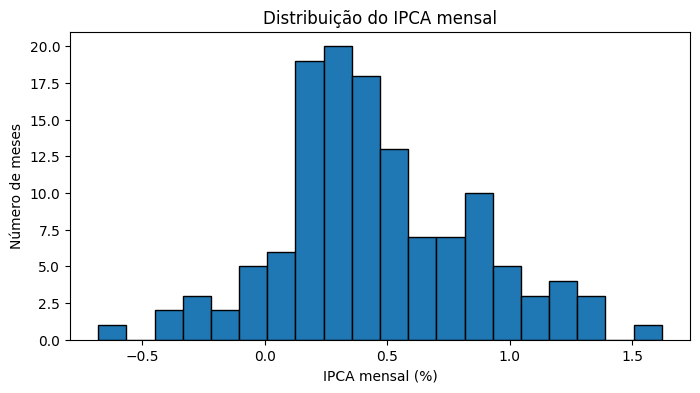

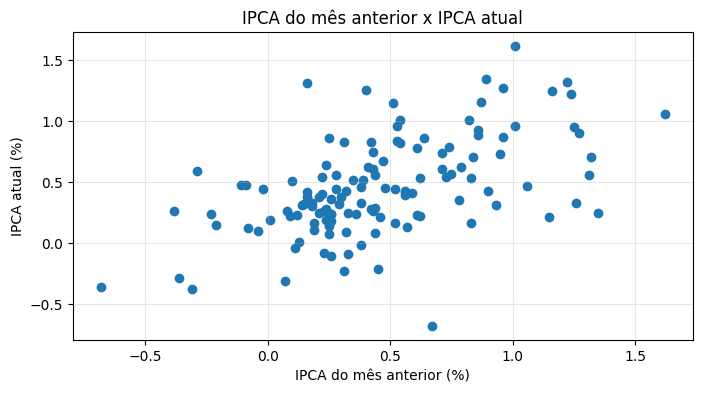

In [9]:
# ==========================================
# Estatísticas descritivas e EDA
# ==========================================

estatisticas = (
    df
    .describe(include="number")
    .T
    .round(3)
)

estatisticas = estatisticas.rename(columns={
    "count": "quantidade",
    "mean": "media",
    "std": "desvio_padrao",
    "min": "minimo",
    "25%": "quartil_1",
    "50%": "mediana",
    "75%": "quartil_3",
    "max": "maximo"
})

display(estatisticas)


# Evolução mensal do IPCA
plt.figure(figsize=(10, 4))

plt.plot(
    df["mes"],
    df["ipca"]
)

plt.title("Evolução mensal do IPCA - 2015 a 2025")
plt.xlabel("Ano")
plt.ylabel("IPCA mensal (%)")
plt.grid(alpha=0.3)

plt.show()


# Distribuição do IPCA
plt.figure(figsize=(8, 4))

plt.hist(
    df["ipca"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do IPCA mensal")
plt.xlabel("IPCA mensal (%)")
plt.ylabel("Número de meses")

plt.show()


# IPCA anterior x IPCA atual
plt.figure(figsize=(8, 4))

plt.scatter(
    df["ipca_anterior"],
    df["ipca"]
)

plt.title("IPCA do mês anterior x IPCA atual")
plt.xlabel("IPCA do mês anterior (%)")
plt.ylabel("IPCA atual (%)")
plt.grid(alpha=0.3)

plt.show()

### Interpretação da análise exploratória

O gráfico temporal mostra que o IPCA mensal variou bastante entre 2015 e 2025, apresentando períodos de inflação mais elevada e também meses com valores negativos, caracterizando deflação.

O histograma mostra que a maior parte dos meses ficou concentrada em faixas de inflação relativamente baixas. Existem valores mais extremos nos dois lados da distribuição, com destaque para alguns meses de inflação mais elevada. A distribuição apresenta uma leve assimetria, portanto não é perfeitamente simétrica.

O gráfico entre IPCA anterior e IPCA atual apresenta uma tendência positiva. Isso sugere que meses com inflação mais elevada tendem, em alguma medida, a ser seguidos por meses também mais elevados, embora exista bastante dispersão entre os pontos.

Visualmente, o gráfico não mostra uma curvatura muito forte. Mesmo assim, foi testado posteriormente um modelo polinomial de grau 2 para verificar se uma curvatura simples produziria melhora real nas métricas de teste.

Os valores extremos foram mantidos na base porque correspondem a observações econômicas reais e não foram identificados como erros de cadastro ou conversão.


In [10]:
# ==========================================
# Correlação com o IPCA
# ==========================================

variaveis = [
    "ipca_anterior",
    "inflacao_eua",
    "var_dolar",
    "selic_anterior",
    "var_ibc_br"
]

correlacao = (
    df[["ipca"] + variaveis]
    .corr()["ipca"]
    .drop("ipca")
)


def classificar(valor):

    valor = abs(valor)

    if valor < 0.20:
        return "Muito fraca"

    elif valor < 0.40:
        return "Fraca"

    elif valor < 0.60:
        return "Moderada"

    elif valor < 0.80:
        return "Forte"

    else:
        return "Muito forte"


resultado = pd.DataFrame({
    "correlacao": correlacao.round(2),

    "direcao": correlacao.apply(
        lambda x: "Positiva"
        if x > 0
        else "Negativa"
    ),

    "forca_da_relacao": correlacao.apply(
        classificar
    )
})

resultado = resultado.loc[
    resultado["correlacao"]
    .abs()
    .sort_values(ascending=False)
    .index
]

display(resultado)

,correlacao,direcao,forca_da_relacao
ipca_anterior,0.53,Positiva,Moderada
inflacao_eua,0.37,Positiva,Fraca
var_dolar,-0.11,Negativa,Muito fraca
selic_anterior,-0.08,Negativa,Muito fraca
var_ibc_br,0.07,Positiva,Muito fraca


### Correlações

O IPCA do mês anterior apresentou a maior correlação com o IPCA atual, em torno de 0,53, indicando uma associação linear positiva moderada.

A inflação dos Estados Unidos apresentou a segunda maior correlação, próxima de 0,37.

As demais variáveis apresentaram correlações menores.

Esses valores representam **associações estatísticas** dentro da base analisada e não devem ser interpretados como relações de causa e efeito.

In [11]:
# ==========================================
# Separação entre treino e teste
# ==========================================

X = df[variaveis]
y = df["ipca"]

# 70% dos meses mais antigos para treino
# 30% dos meses mais recentes para teste
corte = int(len(df) * 0.70)

X_treino = X.iloc[:corte]
X_teste = X.iloc[corte:]

y_treino = y.iloc[:corte]
y_teste = y.iloc[corte:]

print("Dados de treino:", len(X_treino))
print("Dados de teste:", len(X_teste))

print(
    "\nPeríodo de treino:",
    df.loc[X_treino.index[0], "mes"].strftime("%d/%m/%Y"),
    "até",
    df.loc[X_treino.index[-1], "mes"].strftime("%d/%m/%Y")
)

print(
    "Período de teste:",
    df.loc[X_teste.index[0], "mes"].strftime("%d/%m/%Y"),
    "até",
    df.loc[X_teste.index[-1], "mes"].strftime("%d/%m/%Y")
)

Dados de treino: 90
Dados de teste: 39

Período de treino: 01/02/2015 até 01/07/2022
Período de teste: 01/08/2022 até 01/12/2025


### Estratégia de validação e escolha das variáveis

Como os dados possuem ordem temporal, a separação entre treino e teste foi realizada de forma cronológica.

Os primeiros 70% dos meses foram utilizados para treinamento e os 30% mais recentes foram reservados para teste.

Dessa forma, o modelo aprende utilizando dados do passado e é avaliado em meses posteriores, evitando utilizar informações futuras para prever o passado.

Na **Regressão Linear Simples**, foi escolhido o `ipca_anterior` porque ele apresentou a maior correlação linear com o IPCA atual na análise exploratória.

Na **Regressão Linear Múltipla**, foram mantidas as cinco variáveis definidas na pergunta de pesquisa: IPCA anterior, inflação dos EUA, variação do dólar, Selic anterior e variação do IBC-Br. A escolha permite comparar simultaneamente indicadores de inflação passada, cenário internacional, câmbio, juros e atividade econômica.

A regressão polinomial de **grau 2** foi testada como uma comparação adicional. O gráfico exploratório não indicou uma não linearidade muito forte, então foi escolhido apenas o grau 2, evitando aumentar desnecessariamente a complexidade do modelo.


In [12]:
# ==========================================
# Modelos de regressão
# ==========================================

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def avaliar(real, previsto):

    mae = mean_absolute_error(
        real,
        previsto
    )

    rmse = np.sqrt(
        mean_squared_error(
            real,
            previsto
        )
    )

    r2 = r2_score(
        real,
        previsto
    )

    return mae, rmse, r2


# 1. Baseline
baseline = DummyRegressor(
    strategy="mean"
)

baseline.fit(
    X_treino,
    y_treino
)

previsao_baseline = baseline.predict(
    X_teste
)

metricas_baseline = avaliar(
    y_teste,
    previsao_baseline
)


# 2. Regressão Linear Simples
modelo_simples = LinearRegression()

modelo_simples.fit(
    X_treino[["ipca_anterior"]],
    y_treino
)

previsao_simples = modelo_simples.predict(
    X_teste[["ipca_anterior"]]
)

metricas_simples = avaliar(
    y_teste,
    previsao_simples
)


# 3. Regressão Linear Múltipla
modelo_multiplo = LinearRegression()

modelo_multiplo.fit(
    X_treino,
    y_treino
)

previsao_multipla = modelo_multiplo.predict(
    X_teste
)

metricas_multiplo = avaliar(
    y_teste,
    previsao_multipla
)


# 4. Regressão Polinomial - grau 2
modelo_polinomial = make_pipeline(
    PolynomialFeatures(
        degree=2,
        include_bias=False
    ),
    LinearRegression()
)

modelo_polinomial.fit(
    X_treino[["ipca_anterior"]],
    y_treino
)

previsao_polinomial = modelo_polinomial.predict(
    X_teste[["ipca_anterior"]]
)

metricas_polinomial = avaliar(
    y_teste,
    previsao_polinomial
)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


In [ ]:
# ==========================================
# Comparação dos modelos
# ==========================================

comparacao = pd.DataFrame({

    "Modelo": [
        "Baseline",
        "Linear Simples",
        "Linear Múltipla",
        "Polinomial"
    ],

    "MAE": [
        metricas_baseline[0],
        metricas_simples[0],
        metricas_multiplo[0],
        metricas_polinomial[0]
    ],

    "RMSE": [
        metricas_baseline[1],
        metricas_simples[1],
        metricas_multiplo[1],
        metricas_polinomial[1]
    ],

    "R²": [
        metricas_baseline[2],
        metricas_simples[2],
        metricas_multiplo[2],
        metricas_polinomial[2]
    ]
})

display(
    comparacao.round(3)
)


# Coeficientes da regressão múltipla
coeficientes = pd.DataFrame({

    "Variavel": variaveis,

    "Coeficiente":
        modelo_multiplo.coef_
})

print(
    "\nCoeficientes da Regressão Linear Múltipla:"
)

display(
    coeficientes.round(3)
)

# Visualização da curva polinomial de grau 2
faixa_ipca = pd.DataFrame({
    "ipca_anterior": np.linspace(
        X_treino["ipca_anterior"].min(),
        X_treino["ipca_anterior"].max(),
        200
    )
})

curva_polinomial = modelo_polinomial.predict(faixa_ipca)

plt.figure(figsize=(8, 4))
plt.scatter(
    X_treino["ipca_anterior"],
    y_treino,
    alpha=0.6,
    label="Dados de treino"
)
plt.plot(
    faixa_ipca["ipca_anterior"],
    curva_polinomial,
    label="Regressão polinomial - grau 2"
)
plt.title("Curva polinomial: IPCA anterior x IPCA atual")
plt.xlabel("IPCA do mês anterior (%)")
plt.ylabel("IPCA atual (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Escolha e interpretação do modelo

A **Regressão Linear Múltipla** foi escolhida como modelo final por apresentar o melhor equilíbrio entre as métricas.

Apesar de a regressão polinomial apresentar um MAE ligeiramente menor, a regressão múltipla apresentou o **menor RMSE** e o **maior R²** entre os modelos de regressão testados.

A curva polinomial de grau 2 permite uma curvatura suave na relação entre IPCA anterior e IPCA atual. Entretanto, essa flexibilidade adicional não trouxe melhora consistente no conjunto de teste: o modelo polinomial teve RMSE e R² piores que a regressão múltipla. Por isso, a complexidade extra não foi considerada vantajosa.

Os principais coeficientes da Regressão Linear Múltipla foram:

- **IPCA anterior ≈ 0,487:** mantendo as demais variáveis constantes, um aumento de 1 ponto percentual no IPCA anterior esteve associado a aproximadamente 0,487 ponto percentual a mais no IPCA atual.

- **Inflação dos EUA ≈ 0,394:** um aumento de 1 ponto percentual na inflação mensal americana esteve associado a aproximadamente 0,394 ponto percentual a mais no IPCA brasileiro, mantendo as demais variáveis constantes.

- **Variação do dólar ≈ -0,006:** apresentou uma associação pequena e negativa dentro deste modelo.

A Selic anterior e a variação do IBC-Br também apresentaram coeficientes relativamente pequenos.

Esses coeficientes indicam **associação estatística** e não permitem concluir que uma variável causa diretamente alterações no IPCA.


In [ ]:
# ==========================================
# Diagnóstico do modelo final
# ==========================================

from scipy import stats
import statsmodels.api as sm

from statsmodels.stats.stattools import durbin_watson

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

residuos = (
    y_teste
    - previsao_multipla
)


# Real x previsto
plt.figure(figsize=(7, 4))

plt.scatter(
    y_teste,
    previsao_multipla
)

plt.plot(
    [
        y_teste.min(),
        y_teste.max()
    ],
    [
        y_teste.min(),
        y_teste.max()
    ],
    linestyle="--"
)

plt.title("IPCA real x IPCA previsto")
plt.xlabel("IPCA real (%)")
plt.ylabel("IPCA previsto (%)")

plt.show()


# Resíduos x previstos
plt.figure(figsize=(7, 4))

plt.scatter(
    previsao_multipla,
    residuos
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Resíduos x valores previstos")
plt.xlabel("IPCA previsto (%)")
plt.ylabel("Resíduo")

plt.show()


# Distribuição dos resíduos
plt.figure(figsize=(7, 4))

plt.hist(
    residuos,
    bins=15,
    edgecolor="black"
)

plt.title("Distribuição dos resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")

plt.show()


# QQ-Plot
stats.probplot(
    residuos,
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot dos resíduos")
plt.xlabel("Quantis teóricos")
plt.ylabel("Valores observados")

plt.show()


# VIF
vif = pd.DataFrame()

vif["Variavel"] = variaveis

vif["VIF"] = [
    variance_inflation_factor(
        X_treino.values,
        i
    )
    for i in range(
        X_treino.shape[1]
    )
]

print("VIF das variáveis:")

display(
    vif.round(2)
)


# Maiores erros no conjunto de teste
erros = pd.DataFrame({

    "Data":
        df.loc[
            y_teste.index,
            "mes"
        ].dt.strftime("%d/%m/%Y"),

    "IPCA_real":
        y_teste.values,

    "IPCA_previsto":
        previsao_multipla,

    "Erro_absoluto":
        np.abs(residuos.values)
})

erros = erros.sort_values(
    "Erro_absoluto",
    ascending=False
)

print("\nMaiores erros do modelo:")

display(
    erros.head(5).round(3)
)

# Independência temporal aproximada dos resíduos
dw = durbin_watson(residuos)
print("\nDurbin-Watson:", round(dw, 3))
print("Valores próximos de 2 sugerem menor autocorrelação dos resíduos.")


# Distância de Cook para observações influentes no conjunto de treino
X_treino_sm = sm.add_constant(X_treino)

modelo_sm = sm.OLS(
    y_treino,
    X_treino_sm
).fit()

influencia_modelo = modelo_sm.get_influence()
cooks_distance = influencia_modelo.cooks_distance[0]

influentes = pd.DataFrame({
    "Data": df.loc[
        X_treino.index,
        "mes"
    ].dt.strftime("%d/%m/%Y").values,
    "Cook_D": cooks_distance
})

influentes = influentes.sort_values(
    "Cook_D",
    ascending=False
)

limite_cook = 4 / len(X_treino)

print(
    "\nReferência para Distância de Cook (4/n):",
    round(limite_cook, 3)
)
print("Observações com maior influência potencial:")

display(
    influentes.head(5).round(3)
)


### Diagnóstico do modelo final

O gráfico de valores reais e previstos mostra que o modelo consegue acompanhar parte do comportamento do IPCA, mas possui dificuldade principalmente em meses com valores mais extremos.

**Linearidade:** o gráfico de resíduos não apresenta uma curvatura sistemática muito evidente, o que não fornece um sinal forte contra a forma linear. Mesmo assim, a dispersão mostra que a relação está longe de ser perfeita.

**Homoscedasticidade:** não aparece visualmente um padrão de funil extremamente claro nos resíduos, embora existam erros maiores em alguns pontos. Portanto, a constância da variância deve ser interpretada com cautela.

**Normalidade aproximada:** a distribuição dos resíduos fica concentrada ao redor de zero, mas o histograma e o QQ-Plot apresentam desvios nas extremidades. A normalidade dos resíduos, portanto, não é perfeita.

**Independência:** como os dados são mensais e possuem ordem temporal, existe possibilidade de autocorrelação. O notebook calcula a estatística de **Durbin-Watson** como apoio à análise; valores próximos de 2 são mais compatíveis com baixa autocorrelação.

**Colinearidade:** os valores de VIF ficaram abaixo de 5, indicando ausência de um problema relevante de multicolinearidade entre as variáveis explicativas.

**Observações influentes:** a Distância de Cook é utilizada para identificar meses com maior potencial de influência sobre o ajuste. O valor `4/n` é usado apenas como referência. Uma observação com Cook elevado não é removida automaticamente, pois meses extremos podem representar acontecimentos econômicos reais e relevantes.

Os maiores erros de previsão também foram listados separadamente. Eles mostram que acontecimentos específicos e variáveis não incluídas na base podem exercer influência importante sobre a inflação.

Caso os pressupostos lineares se mostrem inadequados em uma análise futura, alternativas possíveis incluem regressão robusta, inclusão de novas defasagens e modelos específicos para séries temporais.


In [15]:
# ==========================================
# Resultado final e exemplos
# ==========================================

# Primeiro e último mês do conjunto de teste
indices = [
    X_teste.index[0],
    X_teste.index[-1]
]

exemplos = X_teste.loc[
    indices
]

previsoes = modelo_multiplo.predict(
    exemplos
)

resultado_final = pd.DataFrame({

    "Data":
        df.loc[
            indices,
            "mes"
        ].dt.strftime("%d/%m/%Y"),

    "IPCA_real":
        y_teste.loc[
            indices
        ],

    "IPCA_previsto":
        previsoes,

    "Erro":
        abs(
            y_teste.loc[indices]
            - previsoes
        )
})

display(
    resultado_final.round(3)
)

print(
    "\nDesempenho do modelo final:"
)

print(
    "MAE:",
    round(
        metricas_multiplo[0],
        3
    )
)

print(
    "RMSE:",
    round(
        metricas_multiplo[1],
        3
    )
)

print(
    "R²:",
    round(
        metricas_multiplo[2],
        3
    )
)

,Data,IPCA_real,IPCA_previsto,Erro
90,01/08/2022,-0.36,-0.139,0.221
128,01/12/2025,0.33,0.330,0.000



Desempenho do modelo final:
MAE: 0.219
RMSE: 0.289
R²: 0.106


# Conclusão

O projeto analisou o comportamento da inflação brasileira entre 2015 e 2025 e investigou se indicadores econômicos nacionais e internacionais estavam associados às variações mensais do IPCA.

Entre as variáveis analisadas, o **IPCA do mês anterior** apresentou a maior associação com o IPCA atual, seguido pela **inflação dos Estados Unidos**.

Em relação às hipóteses iniciais, a hipótese de persistência da inflação foi parcialmente confirmada, pois o IPCA anterior apresentou a maior associação com o IPCA atual. A inflação dos Estados Unidos também apresentou associação positiva. Já dólar, Selic anterior e IBC-Br apresentaram relações menores dentro do modelo utilizado.

Entre os modelos testados, a **Regressão Linear Múltipla** apresentou o melhor equilíbrio geral, com aproximadamente:

- **MAE = 0,219**
- **RMSE = 0,289**
- **R² = 0,106**

O MAE indica que, em média, as previsões ficaram aproximadamente **0,22 ponto percentual distantes do IPCA real** em dados não utilizados no treinamento.

O R² de 0,106 mostra, entretanto, que o modelo explica apenas uma pequena parcela da variação da inflação. Isso indica que o comportamento do IPCA depende de diversos outros fatores que não estão presentes nesta base.

Em **agosto de 2022**, o IPCA real foi de **-0,36%**, enquanto o modelo estimou aproximadamente **-0,139%**. O modelo identificou corretamente um valor negativo, mas subestimou a intensidade da deflação.

Em **dezembro de 2025**, o IPCA real foi de **0,33%** e a previsão ficou próxima de **0,330%**, apresentando erro muito pequeno nesse exemplo.

Esses dois casos são apenas exemplos individuais; a avaliação principal do modelo é feita pelas métricas calculadas sobre todo o conjunto de teste.

Portanto, o modelo é mais útil para **identificar padrões e associações econômicas** do que para prever exatamente a inflação de um mês futuro. Ele não deve ser interpretado como uma ferramenta de causalidade nem como uma previsão econômica definitiva.

Como limitações, o projeto utiliza um conjunto relativamente pequeno de variáveis e uma **Regressão Linear Múltipla** para representar um fenômeno econômico complexo. Futuras análises poderiam adicionar preços de combustíveis, alimentos, energia, commodities e expectativas de inflação, além de testar diferentes defasagens temporais e modelos específicos para séries temporais.

As previsões também devem permanecer dentro de faixas semelhantes às observadas entre 2015 e 2025. Utilizar o modelo em cenários muito diferentes dos dados de treinamento representa **extrapolação** e pode tornar os resultados menos confiáveis.


## Preparação para a aplicação Streamlit

A célula seguinte exporta a base tratada, o modelo final, a ordem das variáveis e as métricas. Esses arquivos poderão ser utilizados pela aplicação Streamlit sem necessidade de repetir todo o treinamento dentro do aplicativo.


In [ ]:
# ==========================================
# Exportação dos arquivos para o Streamlit
# ==========================================

import os
import json
import joblib

os.makedirs("dados", exist_ok=True)
os.makedirs("modelo", exist_ok=True)

# Base tratada
df.to_csv(
    "dados/base_tratada.csv",
    index=False
)

# Modelo final
joblib.dump(
    modelo_multiplo,
    "modelo/modelo_multiplo.pkl"
)

# Ordem das variáveis esperada pelo modelo
joblib.dump(
    variaveis,
    "modelo/variaveis.pkl"
)

# Métricas do modelo final
metricas_app = {
    "MAE": round(metricas_multiplo[0], 6),
    "RMSE": round(metricas_multiplo[1], 6),
    "R2": round(metricas_multiplo[2], 6)
}

with open(
    "modelo/metricas.json",
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        metricas_app,
        arquivo,
        ensure_ascii=False,
        indent=2
    )

print("Arquivos preparados para o Streamlit:")
print("- dados/base_tratada.csv")
print("- modelo/modelo_multiplo.pkl")
print("- modelo/variaveis.pkl")
print("- modelo/metricas.json")
